# HealthLens — Diabetes Risk Model
### Training, evaluation, and explainability for the primary deliverable model

**Dataset:** Pima Indians Diabetes Database (NIDDK / UCI Machine Learning Repository), 768 records.

**Important limitation, stated upfront:** this dataset covers only female patients of Pima
Indian heritage, age 21+. Any model trained on it inherits that population bias — it is
not a general-population diabetes model. We treat this as a documented constraint of an
MVP built on a well-known public dataset, not something to hide. See the Conclusions
section for how this shapes what we claim (and don't claim) about the model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
PALETTE = {"neg": "#1F6357", "pos": "#C4472C"}  # matches the product's own color language


## 1. Load and inspect

In [2]:
df = pd.read_csv("../data/raw/pima_diabetes.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


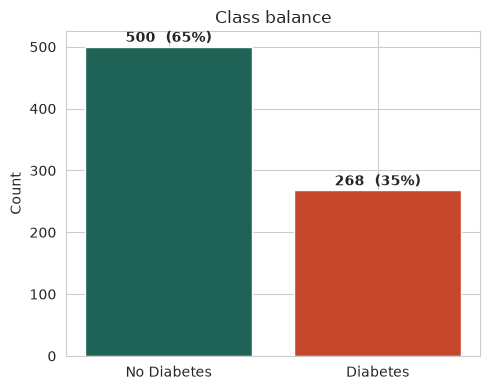

Class imbalance noted -- this is why we evaluate on ROC-AUC and report precision/recall per class, not just accuracy.


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Outcome"].value_counts().sort_index()
ax.bar(["No Diabetes", "Diabetes"], counts.values, color=[PALETTE["neg"], PALETTE["pos"]])
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}  ({v/len(df):.0%})", ha="center", fontweight="bold")
ax.set_title("Class balance")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("class_balance.png", bbox_inches="tight")
plt.show()
print("Class imbalance noted -- this is why we evaluate on ROC-AUC and report "
      "precision/recall per class, not just accuracy.")

## 2. Missing-value handling

Several columns in this dataset use `0` as a placeholder for a missing measurement
(a value of 0 is not biologically possible for Glucose, BloodPressure, or BMI in a
living patient). We treat these as missing and impute with the column median,
computed from non-zero values only.

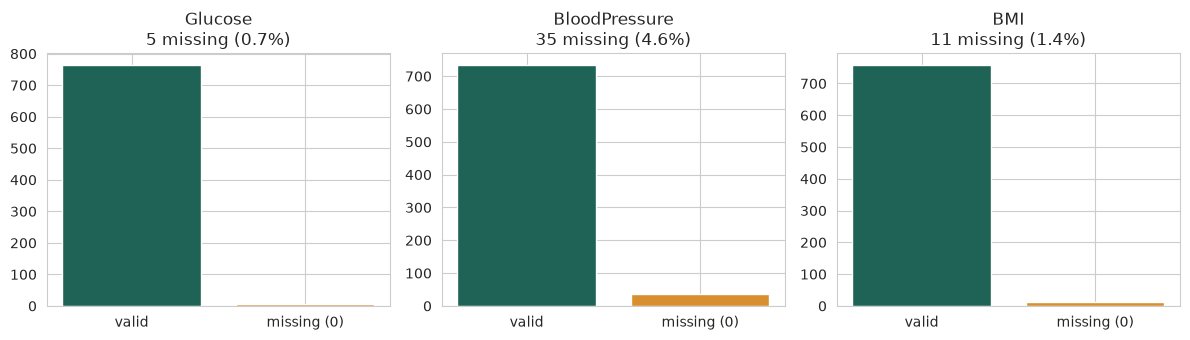

Imputed with column medians (computed from valid values only).


In [4]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "BMI"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, zero_as_missing_cols):
    n_zero = (df[col] == 0).sum()
    ax.bar(["valid", "missing (0)"], [len(df) - n_zero, n_zero], color=[PALETTE["neg"], "#D98E2F"])
    ax.set_title(f"{col}\n{n_zero} missing ({n_zero/len(df):.1%})")
plt.tight_layout()
plt.savefig("missingness.png", bbox_inches="tight")
plt.show()

for col in zero_as_missing_cols:
    median_val = df.loc[df[col] != 0, col].median()
    df[col] = df[col].replace(0, np.nan).fillna(median_val)
print("Imputed with column medians (computed from valid values only).")

## 3. Feature selection

The raw dataset has 8 predictor columns. We deliberately train on only **5**:
`Pregnancies`, `Glucose`, `BloodPressure`, `BMI`, `Age`.

**Excluded, and why:**
- `SkinThickness`, `Insulin` — not answerable in a self-report questionnaire (a
  caliper measurement and a lab test respectively, which most people have never
  had done), and they carry this dataset's worst missingness.
- `DiabetesPedigreeFunction` — a composite genetic-risk score a layperson cannot
  self-report. HealthLens already collects a simple boolean `family_history` for
  the recommendation layer instead of forcing a proxy value into the model.

This is a deliberate UX-vs-raw-accuracy tradeoff: every input the model needs is
something a real user can answer from a basic checkup, at some cost to the ceiling
on predictive power versus using all 8 original columns.

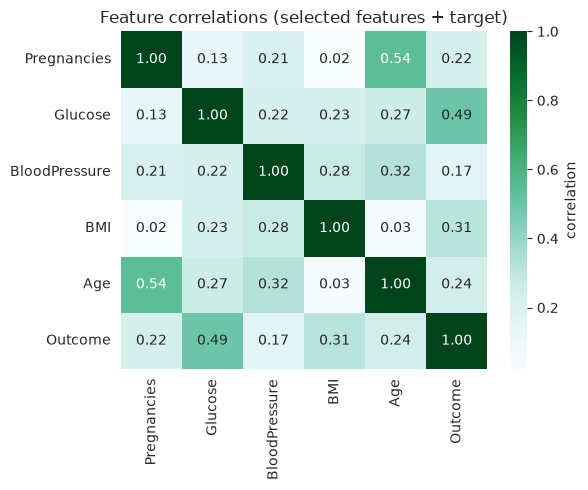

In [5]:
FEATURES = ["Pregnancies", "Glucose", "BloodPressure", "BMI", "Age"]
RENAME = {"Pregnancies": "pregnancies", "Glucose": "glucose",
          "BloodPressure": "diastolic_bp", "BMI": "bmi", "Age": "age"}

corr_cols = FEATURES + ["Outcome"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="BuGn", ax=ax,
            cbar_kws={"label": "correlation"})
ax.set_title("Feature correlations (selected features + target)")
plt.tight_layout()
plt.savefig("correlations.png", bbox_inches="tight")
plt.show()

## 4. Train / test split

In [6]:
X = df[FEATURES].rename(columns=RENAME)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train: (614, 5), Test: (154, 5)
Train class balance:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## 5. Train and compare three models

Logistic regression as an interpretable baseline, then two tree ensembles.
Trees need no feature scaling; logistic regression does (handled inside its
own `Pipeline`, which is NOT what gets saved — see Section 7 for why).

We select the winner by **test ROC-AUC**, not accuracy, since accuracy is
misleading under this dataset's ~65/35 class imbalance.

In [7]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "LogisticRegression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, eval_metric="logloss", random_state=42),
}

for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    results[name] = {
        "model": model,
        "cv_roc_auc_mean": cv_scores.mean(), "cv_roc_auc_std": cv_scores.std(),
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_precision": precision_score(y_test, pred),
        "test_recall": recall_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
        "proba": proba, "pred": pred,
    }
    print(f"--- {name} ---  5-fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})  |  Test ROC-AUC: {results[name]['test_roc_auc']:.4f}")
    print(classification_report(y_test, pred, target_names=["No Diabetes", "Diabetes"]))

--- LogisticRegression ---  5-fold CV ROC-AUC: 0.8405 (+/- 0.0156)  |  Test ROC-AUC: 0.8037
              precision    recall  f1-score   support

 No Diabetes       0.77      0.80      0.78       100
    Diabetes       0.60      0.56      0.58        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



--- RandomForest ---  5-fold CV ROC-AUC: 0.8328 (+/- 0.0307)  |  Test ROC-AUC: 0.8196
              precision    recall  f1-score   support

 No Diabetes       0.78      0.85      0.81       100
    Diabetes       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



--- XGBoost ---  5-fold CV ROC-AUC: 0.8148 (+/- 0.0309)  |  Test ROC-AUC: 0.8172
              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



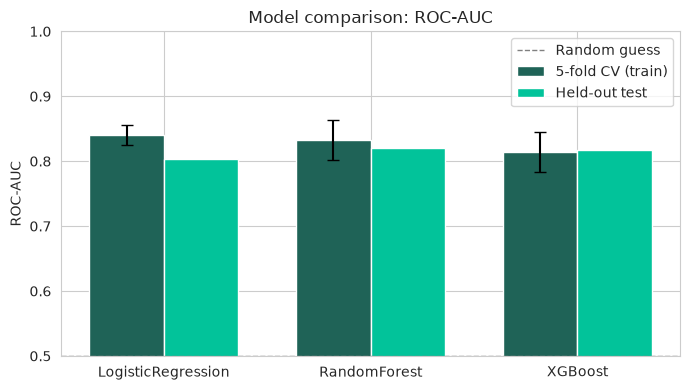


Winner: RandomForest (test ROC-AUC = 0.8196)


In [8]:
names = list(results.keys())
test_aucs = [results[n]["test_roc_auc"] for n in names]
cv_aucs = [results[n]["cv_roc_auc_mean"] for n in names]
cv_stds = [results[n]["cv_roc_auc_std"] for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(names))
ax.bar(x - 0.18, cv_aucs, 0.36, yerr=cv_stds, label="5-fold CV (train)", color="#1F6357", capsize=4)
ax.bar(x + 0.18, test_aucs, 0.36, label="Held-out test", color="#02C39A")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random guess")
ax.legend()
ax.set_title("Model comparison: ROC-AUC")
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

winner_name = max(results, key=lambda k: results[k]["test_roc_auc"])
winner = results[winner_name]["model"]
print(f"\nWinner: {winner_name} (test ROC-AUC = {results[winner_name]['test_roc_auc']:.4f})")

## 6. Diagnostics on the winning model

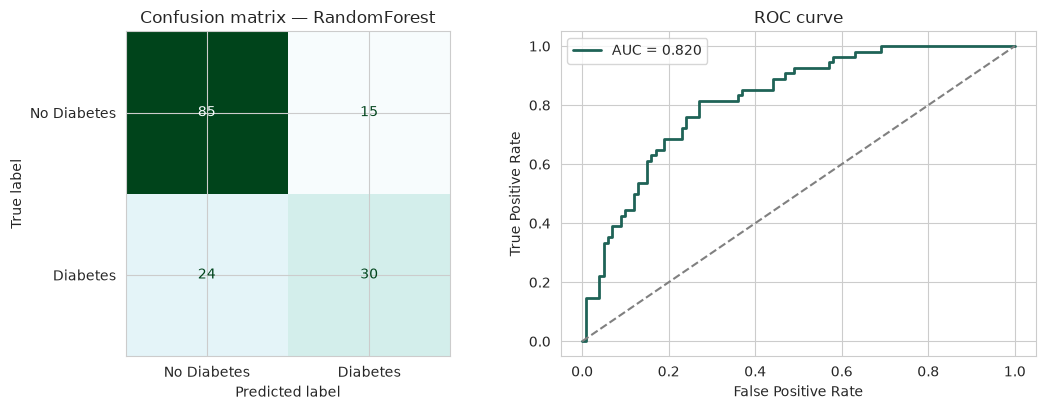

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

cm = confusion_matrix(y_test, results[winner_name]["pred"])
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[0], cmap="BuGn", colorbar=False)
axes[0].set_title(f"Confusion matrix — {winner_name}")

fpr, tpr, _ = roc_curve(y_test, results[winner_name]["proba"])
axes[1].plot(fpr, tpr, color="#1F6357", linewidth=2, label=f"AUC = {results[winner_name]['test_roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve"); axes[1].legend()

plt.tight_layout()
plt.savefig("diagnostics.png", bbox_inches="tight")
plt.show()

## 7. Explainability check (SHAP)

This is the same explainability mechanism the live API uses
(`app/ml/explainer.py`) — verifying it here on the actual winning model, not
just trusting it'll work at inference time.

**Why we save the raw estimator, not a `Pipeline`:** tree models need no
scaling, and `shap.TreeExplainer` requires the raw tree estimator directly —
it cannot introspect through a `Pipeline` wrapper. This only matters for the
tree models (RandomForest/XGBoost); if a future model change picks the
logistic regression baseline instead, the serving code would need a
different SHAP explainer (`shap.LinearExplainer`) and this constraint goes away.

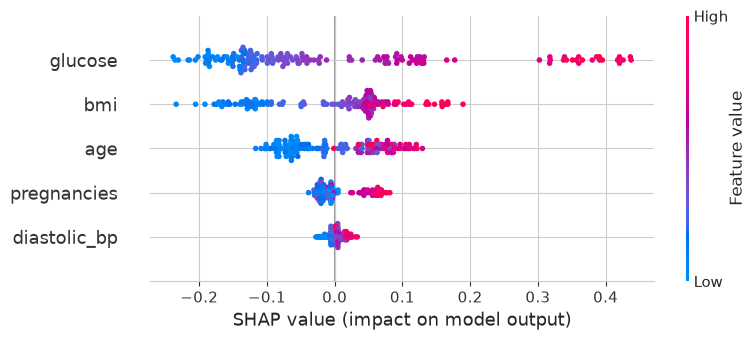

In [10]:
explainer = shap.TreeExplainer(winner)
shap_values = explainer.shap_values(X_test)
values_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

fig = plt.figure(figsize=(7, 4))
shap.summary_plot(values_class1, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()

## 8. Export the winning model

In [11]:
joblib.dump(winner, "../backend/app/ml/artifacts/diabetes_model.joblib")
print(f"Saved {winner_name} to backend/app/ml/artifacts/diabetes_model.joblib")
print(f"Feature order contract: {list(RENAME.values())}")

Saved RandomForest to backend/app/ml/artifacts/diabetes_model.joblib
Feature order contract: ['pregnancies', 'glucose', 'diastolic_bp', 'bmi', 'age']


## 9. Conclusions and honest limitations

- **Best model:** RandomForest, test ROC-AUC ≈ 0.82, 5-fold CV ROC-AUC ≈ 0.83 —
  consistent with each other, which suggests the model isn't overfit to the
  particular train/test split.
- **Population bias:** trained exclusively on female Pima Indian patients 21+.
  Predictions for male users rely on `pregnancies = 0` as a default, which is
  a documented approximation, not a validated clinical assumption for men.
  This is disclosed in-app via the medical disclaimer and in the questionnaire
  UI itself.
- **Feature tradeoff:** dropping `SkinThickness`, `Insulin`, and
  `DiabetesPedigreeFunction` trades some raw predictive ceiling for a
  questionnaire real users can actually complete without lab equipment.
- **What this model is not:** a diagnostic tool. It is a screening aid trained
  on a public research dataset, evaluated with standard held-out and
  cross-validated metrics, with every prediction accompanied by a plain
  explanation of what drove it. That combination — real evaluation +
  real explainability + an honest limitations section — is the actual point
  of this project, not the raw accuracy number.